# Übung Histogramme

In [25]:
# package import
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [26]:
# Bilddateien einladen
image = cv2.imread(r'images/crew.tif', cv2.IMREAD_GRAYSCALE)

#Datentyp:
imageDataType = image.dtype
#Bildgröße
imageShape = image.shape

# Ausgabe der Daten
print(f'Datentyp des Bildes: {imageDataType}')
print(f'Größe des Bildes: {imageShape}')

# Anzeige des Bildes
fig = px.imshow(image, color_continuous_scale='gray')
fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    width=500,
    height=500)
fig.show()

Datentyp des Bildes: uint8
Größe des Bildes: (269, 200)


## Histogramm

### Aufgabe:

Implementieren Sie die Funktion `myHist`, die aus einem 8bit Graustufenbild ein Histogramm berechnet.
    + Verwenden Sie eine Klassengröße von 1, sodass das Histogramm die Werte in 2^8 bins unterteilt.

In [27]:
#----------------------------------
# Histogramm berechnen, Anzahl der Pixel in jedem bin zählen
#--------------------------------
def myHist(gray_image):
    #--------------------------------
    # 8 Bit-Quantisierung
    #--------------------------------
    b = 8
    #--------------------------------
    # Anzahl der Helligkeitsstufen
    #--------------------------------
    q = 2**b
    #--------------------------------
    # Histogramm initialisieren
    #--------------------------------
    h = np.zeros(q)
    
    #--------------------------------
    # Häufigkeiten ermitteln
    #--------------------------------
    #######
    ## ENTER YOUR CODE HERE
    #######

    for y in range(gray_image.shape[0]):
        for x in range(gray_image.shape[1]):
            h[gray_image[y,x]] += 1

    return h


Anzeigen von Histogramm und Bild

Text(0, 0.5, 'Anzahl')

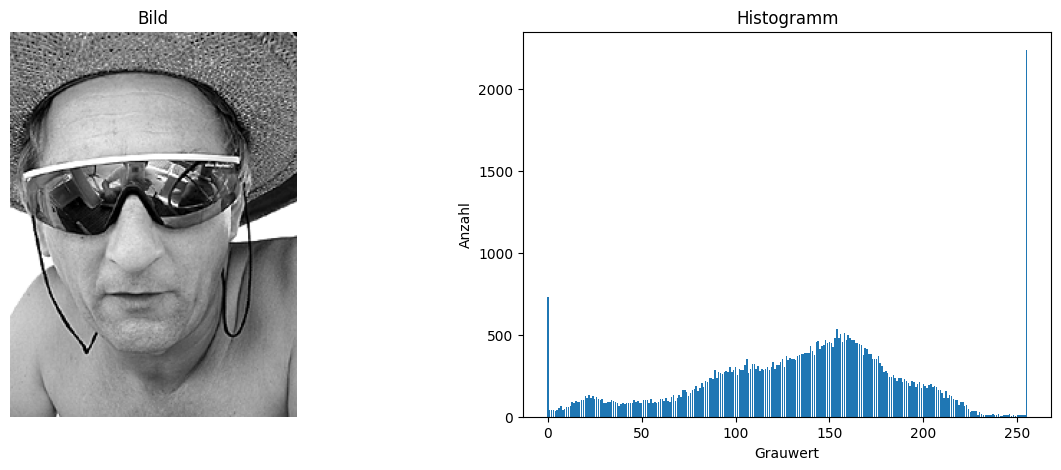

In [28]:
# Histogramm berechnen
histo = myHist(image)

# Bild und Histogramm anzeigen
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
# Bild anzeigen
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Bild')
axs[0].axis('off')

axs[1].bar(range(len(histo)), histo)
axs[1].set_title('Histogramm')
axs[1].set_xlabel('Grauwert')
axs[1].set_ylabel('Anzahl')

## Kummuliertes Histogramm

### Aufgabe:

Implementieren Sie die Funktion `myCumHist`, die aus einem 8bit Graustufenbild das kummulierte Histogramm berechnet.Verwenden Sie hierzu die Funktion `myHist`

In [29]:
#--------------------------------
# Kumuliatives Histogramm
# Argument: Einkanaliges Bild
#--------------------------------
def myCumHist(gray_image):
    
    #--------------------------------
    # Histogramm
    #--------------------------------
    ######
    ## ENTER YOUR CODE HERE
    ######



    h = myHist(gray_image)
    
    #--------------------------------
    # Initialisieren
    #--------------------------------
    ch    = np.zeros(h.shape[0])
    ch[0] = h[0]
    
    #--------------------------------
    # Aufsummieren
    #--------------------------------
    for i in range(h.shape[0]-1):
        ch[i+1] = ch[i]+h[i]
    
    return ch

**Anzeigen der Histogramme**

In [30]:
# Funktionsdefinition für ein vereinfachtes Anzeigen von Bild, Histogramm und kumuliertem Histogramm

def displayImageAndAllHist(image):

    histo = myHist(image)
    cumHisto = myCumHist(image)
    
    # Matplotlib Plot mit Bild und Histogramm
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Bild anzeigen
    axs[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title('Bild')
    axs[0].axis('off')

    # Histogramm
    axs[1].bar(range(len(histo)), histo)
    axs[1].set_title('Histogramm')
    axs[1].set_xlabel('Grauwert')
    axs[1].set_ylabel('Anzahl')

    # Kumuliertes Histogramm
    axs[2].plot(range(len(cumHisto)), cumHisto, color='red')
    axs[2].set_title('Kumuliertes Histogramm')
    axs[2].set_xlabel('Grauwert')
    axs[2].set_ylabel('Kumuliert')

    plt.tight_layout()
    plt.show()

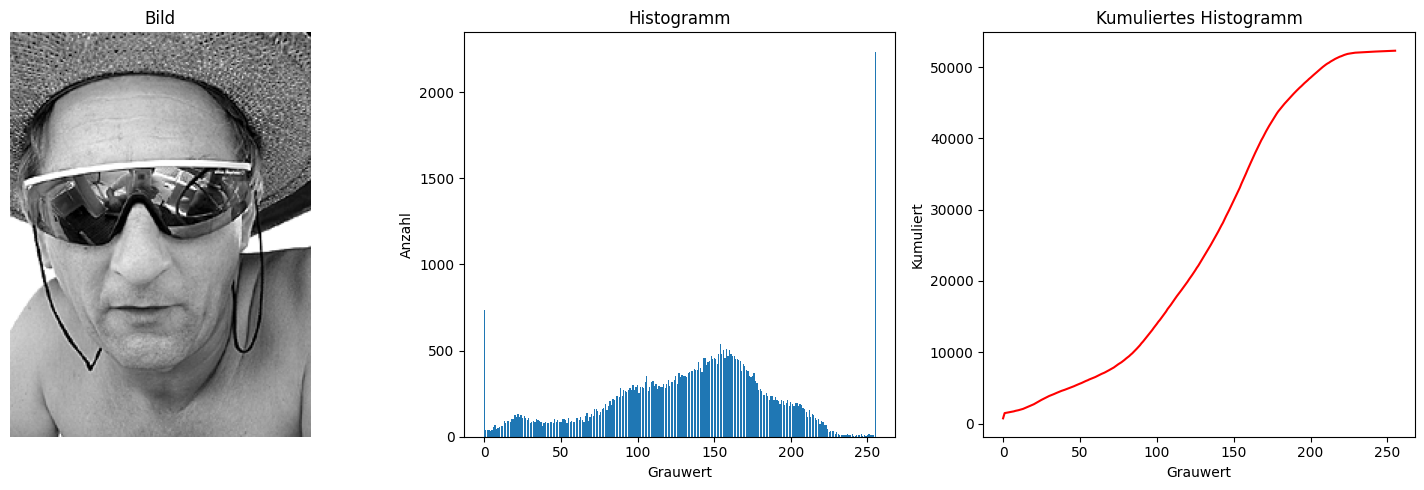

In [31]:
# anzeigen von Bild und Histogrammen
displayImageAndAllHist(image)

### Einige Histogramme 

#### Aufgabe:
schauen Sie sich die Histogramme der folgenden Bilder an und überlegen Sie wieso diese so aussehen

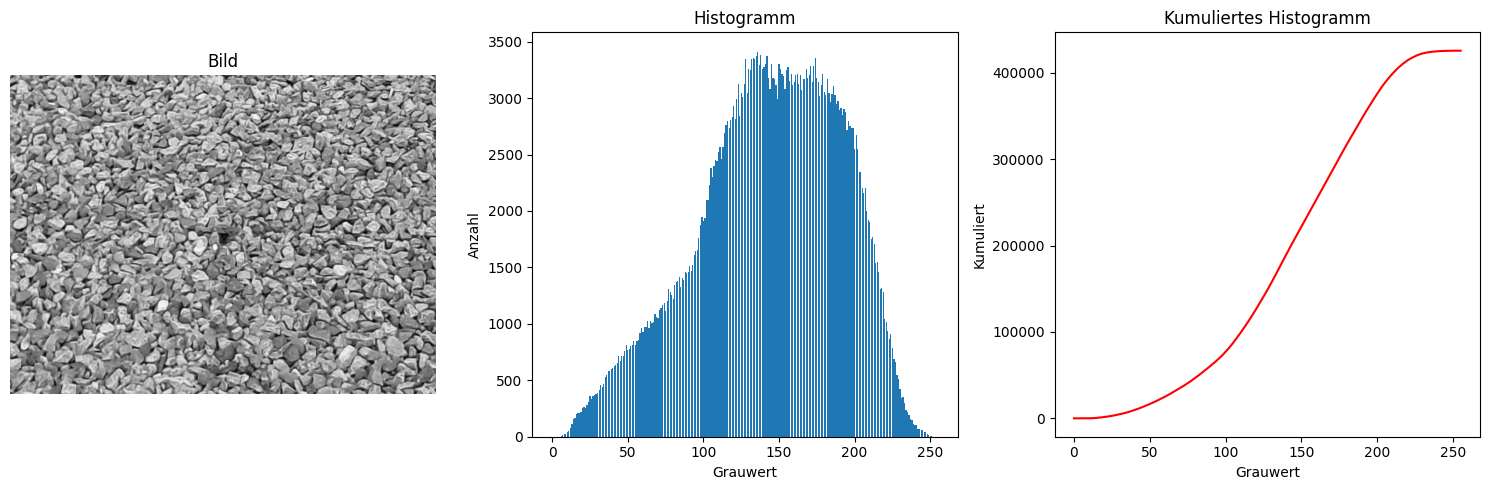

In [32]:
img_stones1 = cv2.imread(r'images/stones1.jpg', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_stones3)

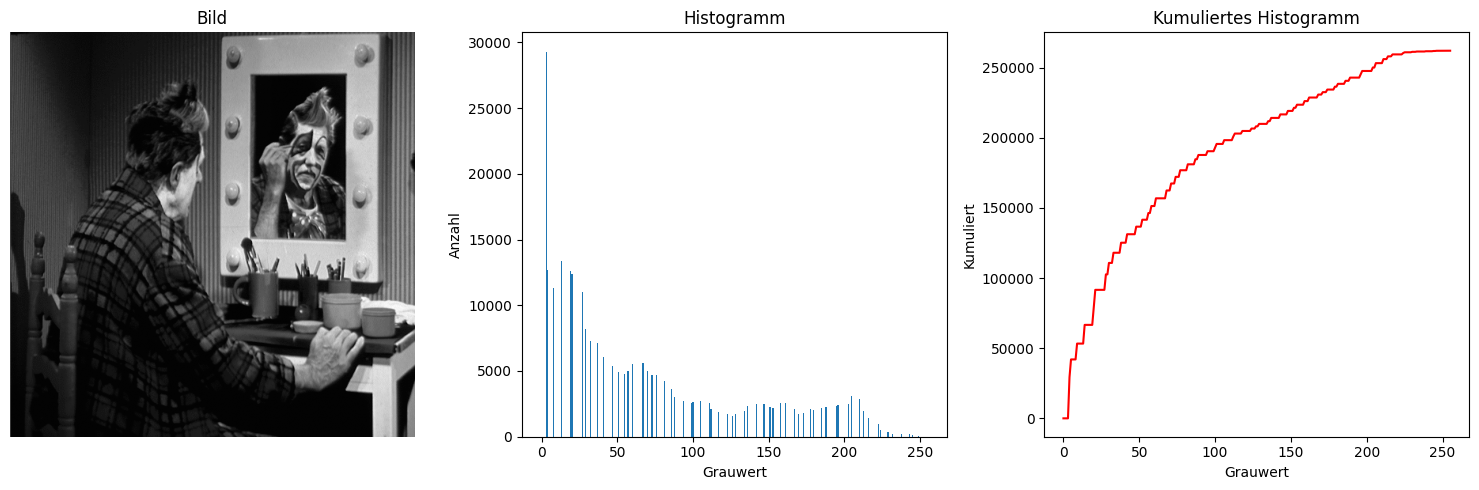

In [33]:
img_clown = cv2.imread(r'images/clown.bmp', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_clown)

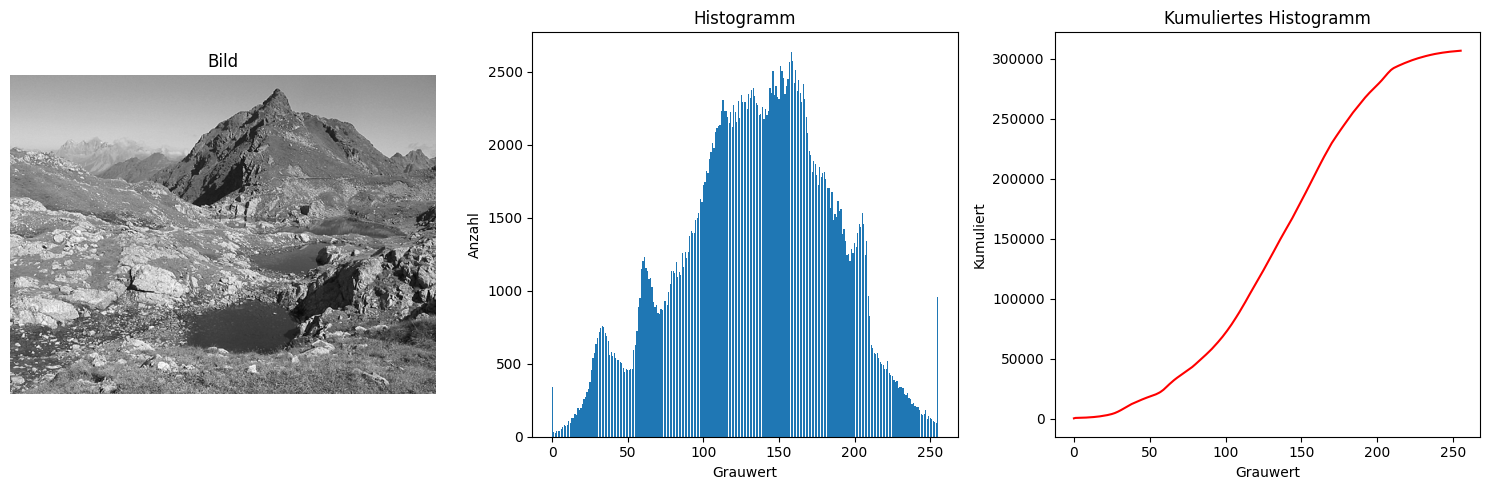

In [34]:
img_alps = cv2.imread(r'images/alps.tif', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_alps)

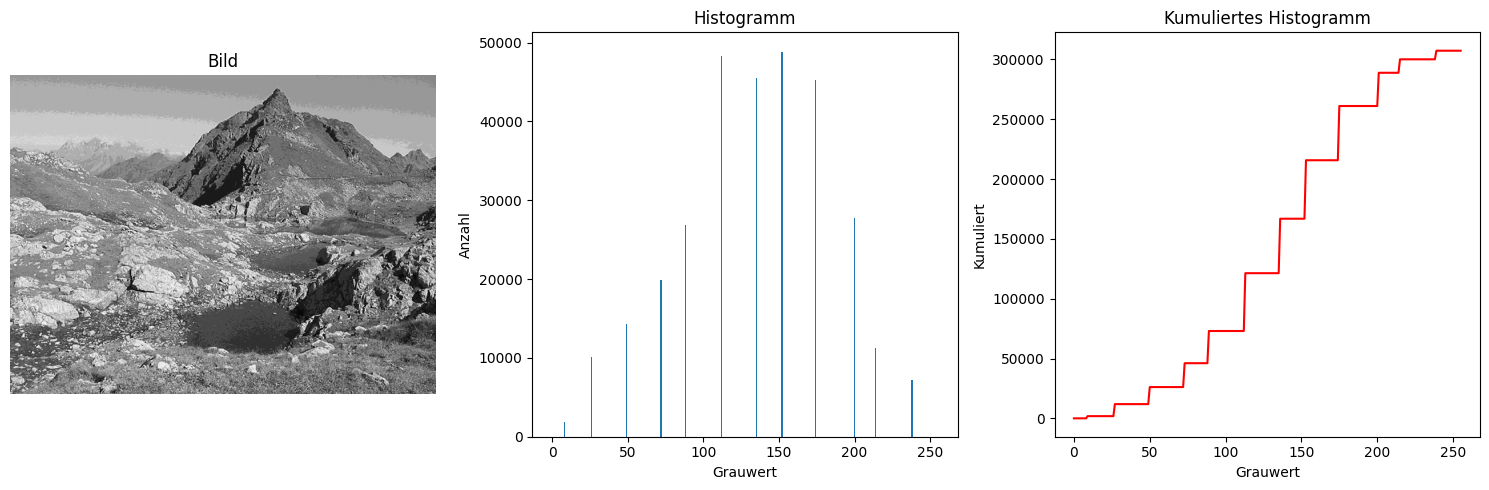

In [35]:
img_alps2 = cv2.imread(r'images/alps_comp.tif', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_alps2)

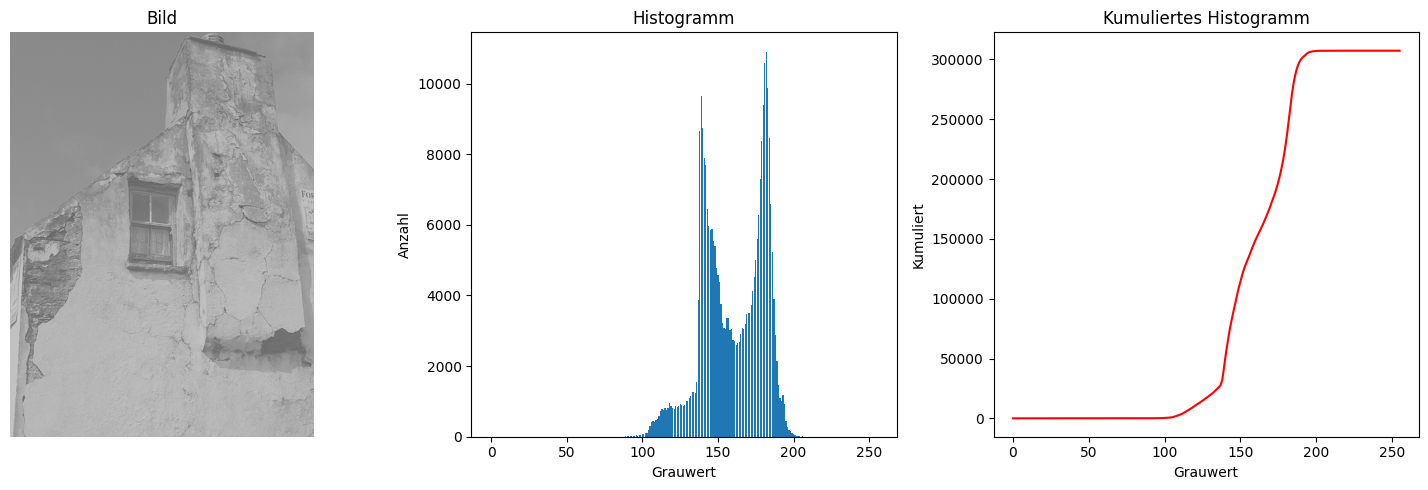

In [36]:
img_ireland = cv2.imread(r'images/ireland.tif', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_ireland)